# 1. Import Data

In [97]:
import pandas as pd
import numpy as np
pd.set_option('display.max_column', None)
pd.set_option('display.max_row', None)

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, TargetEncoder

from imblearn.over_sampling import SMOTENC

In [98]:
df = pd.read_csv('../Datasets/Processed/processed_data.csv')

# 2. Data Preview

In [99]:
df.head()

,Gender,Age,Under 30,Senior Citizen,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churn Label,Population,30 to 64,Household Size,Is Alone,Receive Refund,Total Services Subscribed,Cost per GB,Historical Avg Monthly Charge,Bill Shock,Tenure Group,Referral a Friend,Under-Utilizing Unlimited
0,Male,78,No,Yes,No,0,Los Angeles,90022,34.023810,-118.156582,0,1,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,Yes,68701,No,1,Yes,No,2,4.956244,39.650000,No,New (0-1y),No,No
1,Female,74,No,Yes,Yes,1,Los Angeles,90063,34.044271,-118.185237,1,8,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,Yes,55668,No,3,No,No,2,4.744115,79.162500,Yes,New (0-1y),Yes,Yes
2,Male,71,No,Yes,No,3,Los Angeles,90065,34.108833,-118.229715,0,18,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,Yes,47534,No,4,No,Yes,4,1.835577,97.363889,No,Standard (1-2y),No,No
3,Female,78,No,Yes,Yes,1,Inglewood,90303,33.936291,-118.332639,1,25,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,Yes,27778,No,3,No,Yes,4,8.208326,100.580000,No,Loyal (2-4y),Yes,Yes
4,Female,80,No,Yes,Yes,1,Whittier,90602,33.972119,-118.020188,1,37,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,Yes,26265,No,3,No,No,1,5.464282,77.517568,No,Loyal (2-4y),Yes,Yes


In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             7043 non-null   str    
 1   Age                                7043 non-null   int64  
 2   Under 30                           7043 non-null   str    
 3   Senior Citizen                     7043 non-null   str    
 4   Married                            7043 non-null   str    
 5   Number of Dependents               7043 non-null   int64  
 6   City                               7043 non-null   str    
 7   Zip Code                           7043 non-null   int64  
 8   Latitude                           7043 non-null   float64
 9   Longitude                          7043 non-null   float64
 10  Number of Referrals                7043 non-null   int64  
 11  Tenure in Months                   7043 non-null   int64  
 12  Pho

In [101]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Population,Household Size,Total Services Subscribed,Cost per GB,Historical Avg Monthly Charge
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7.043000e+03,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,22139.603294,1.951725,2.813006,4.567255e+05,64.762914
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,21152.392837,1.220132,2.363415,8.742899e+05,30.189784
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,11.000000,1.000000,0.000000,2.923529e-01,13.775000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,2344.000000,1.000000,1.000000,2.471527e+00,35.935156
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,17554.000000,2.000000,3.000000,4.702629e+00,70.337500
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,36125.000000,2.000000,5.000000,2.333326e+01,90.174158
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,105285.000000,11.000000,8.000000,2.690000e+06,121.400000


In [102]:
df.isna().sum().sum()

np.int64(0)

# 3. Data Splitting

In [103]:
X = df.drop('Churn Label', axis=1).copy()
y = df['Churn Label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.7, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f'Training Samples    : {X_train.shape[0]}')
print(f'Validation Samples  : {X_val.shape[0]}')
print(f'Testing Samples     : {X_test.shape[0]}')

Training Samples    : 4930
Validation Samples  : 1056
Testing Samples     : 1057


# 4. Handling Imbalance Data

In [104]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 5963 to 6017
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   str    
 1   Age                                4930 non-null   int64  
 2   Under 30                           4930 non-null   str    
 3   Senior Citizen                     4930 non-null   str    
 4   Married                            4930 non-null   str    
 5   Number of Dependents               4930 non-null   int64  
 6   City                               4930 non-null   str    
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   int64  
 11  Tenure in Months                   4930 non-null   int64  
 12  Phone

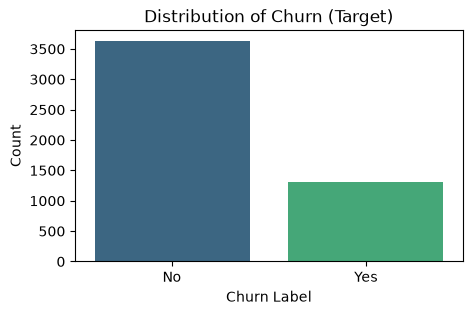

In [105]:
plt.figure(figsize=(5, 3))
sns.countplot(
    x=y_train,
    palette='viridis'
)
plt.title('Distribution of Churn (Target)')
plt.ylabel('Count')
plt.show()

In [106]:
cat_cols = X_train.select_dtypes(include='object').columns.to_list()

smote_nc = SMOTENC(categorical_features=cat_cols, random_state=42)
X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

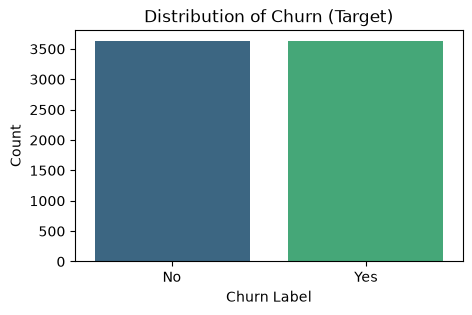

In [107]:
plt.figure(figsize=(5, 3))
sns.countplot(
    x=y_train_resampled,
    palette='viridis'
)
plt.title('Distribution of Churn (Target)')
plt.ylabel('Count')
plt.show()

# 4. Data Transformation

## 4.1 Data Encoding

### 4.1.1 Binary Encoding

In [108]:
X_dimensions = [X_train, X_val, X_test]

yes_no_cols = [
    'Under 30',
    'Senior Citizen',
    'Married',
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music',
    'Unlimited Data',
    'Paperless Billing',
    '30 to 64',
    'Is Alone',
    'Receive Refund',
    'Bill Shock',
    'Referral a Friend',
    'Under-Utilizing Unlimited'
]

for X_dimension in X_dimensions:
    X_dimension['Gender'] = X_dimension['Gender'].map(
        {'Male': 1, 'Female': 0}
    )
    X_dimension[yes_no_cols] = (X_dimension[yes_no_cols] == 'Yes').astype(int)

y_train, y_val, y_test = [
    y.map({'Yes': 1, 'No': 0}) for y in [y_train, y_val, y_test]
]

In [109]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 5963 to 6017
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   int64  
 1   Age                                4930 non-null   int64  
 2   Under 30                           4930 non-null   int64  
 3   Senior Citizen                     4930 non-null   int64  
 4   Married                            4930 non-null   int64  
 5   Number of Dependents               4930 non-null   int64  
 6   City                               4930 non-null   str    
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   int64  
 11  Tenure in Months                   4930 non-null   int64  
 12  Phone

In [110]:
y_train.info()

<class 'pandas.Series'>
Index: 4930 entries, 5963 to 6017
Series name: Churn Label
Non-Null Count  Dtype
--------------  -----
4930 non-null   int64
dtypes: int64(1)
memory usage: 77.0 KB


### 4.1.2 One Hot Encoding

In [111]:
cols_to_ohe = [
    'Internet Type',
    'Contract',
    'Payment Method',
    'Tenure Group'
]

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

ohe.set_output(transform="pandas") 

encoded_df_train = ohe.fit_transform(X_train[cols_to_ohe])
X_train_ohe = pd.concat([X_train.drop(cols_to_ohe, axis=1), encoded_df_train], axis=1)

encoded_df_val = ohe.transform(X_val[cols_to_ohe])
X_val_ohe = pd.concat([X_val.drop(cols_to_ohe, axis=1), encoded_df_val], axis=1)

encoded_df_test = ohe.transform(X_test[cols_to_ohe])
X_test_ohe = pd.concat([X_test.drop(cols_to_ohe, axis=1), encoded_df_test], axis=1)

In [112]:
X_train_ohe.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 5963 to 6017
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   int64  
 1   Age                                4930 non-null   int64  
 2   Under 30                           4930 non-null   int64  
 3   Senior Citizen                     4930 non-null   int64  
 4   Married                            4930 non-null   int64  
 5   Number of Dependents               4930 non-null   int64  
 6   City                               4930 non-null   str    
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   int64  
 11  Tenure in Months                   4930 non-null   int64  
 12  Phone

### 4.1.3 Target Encoding

In [113]:
te = TargetEncoder(smooth='auto')

X_train_te = X_train_ohe.copy()
X_val_te = X_val_ohe.copy()
X_test_te = X_test_ohe.copy()

X_train_te['City'] = te.fit_transform(X_train_ohe[['City']], y_train)
X_val_te['City'] = te.transform(X_val_ohe[['City']])
X_test_te['City'] = te.transform(X_test_ohe[['City']])

In [114]:
X_train_te.info()

<class 'pandas.DataFrame'>
Index: 4930 entries, 5963 to 6017
Data columns (total 57 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             4930 non-null   int64  
 1   Age                                4930 non-null   int64  
 2   Under 30                           4930 non-null   int64  
 3   Senior Citizen                     4930 non-null   int64  
 4   Married                            4930 non-null   int64  
 5   Number of Dependents               4930 non-null   int64  
 6   City                               4930 non-null   float64
 7   Zip Code                           4930 non-null   int64  
 8   Latitude                           4930 non-null   float64
 9   Longitude                          4930 non-null   float64
 10  Number of Referrals                4930 non-null   int64  
 11  Tenure in Months                   4930 non-null   int64  
 12  Phone

## 4.2 Data Scaling (Handling Outlier & Scale Correction)

### a. Log Transformation (Continuous Numeric Only) + Standard Scaler

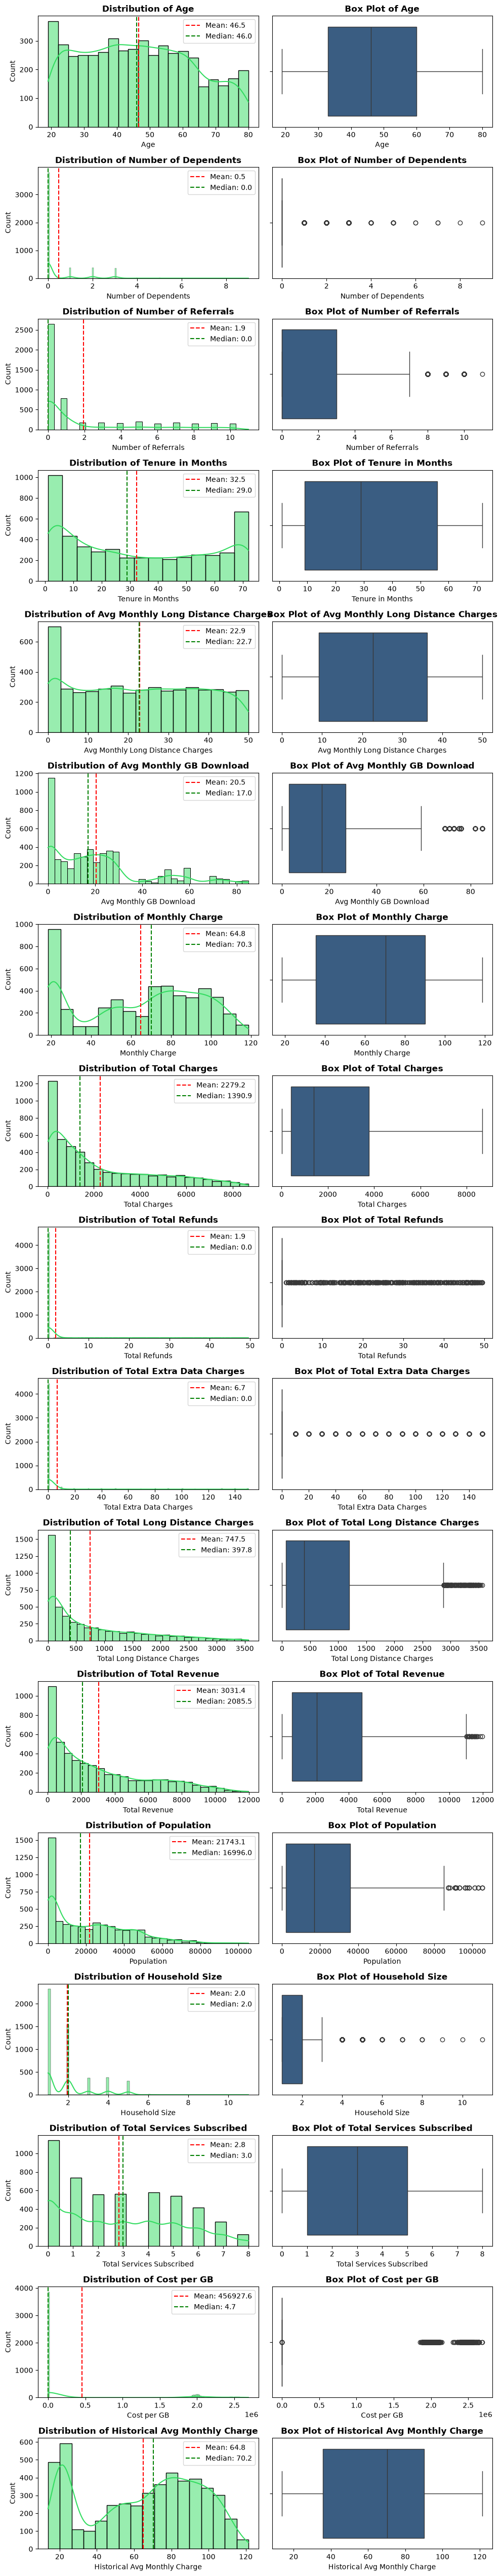

In [91]:
num_cols = [
    'Age',
    'Number of Dependents',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Population',
    'Household Size',
    'Total Services Subscribed',
    'Cost per GB',
    'Historical Avg Monthly Charge'
]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train_te,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train_te[col].mean()
    median = X_train_te[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train_te,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
cols_to_log = [
    # 'Number of Dependents',
    # 'Number of Referrals',
    'Avg Monthly GB Download',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Population',
    # 'Household Size',
    'Cost per GB'
]

X_train_log = X_train_te.copy()
X_val_log = X_val_te.copy()
X_test_log = X_test_te.copy()

# Log-Transform
X_train_log[cols_to_log] = np.log1p(X_train_te[cols_to_log].copy())
X_val_log[cols_to_log] = np.log1p(X_val_te[cols_to_log].copy())
X_test_log[cols_to_log] = np.log1p(X_test_te[cols_to_log].copy())

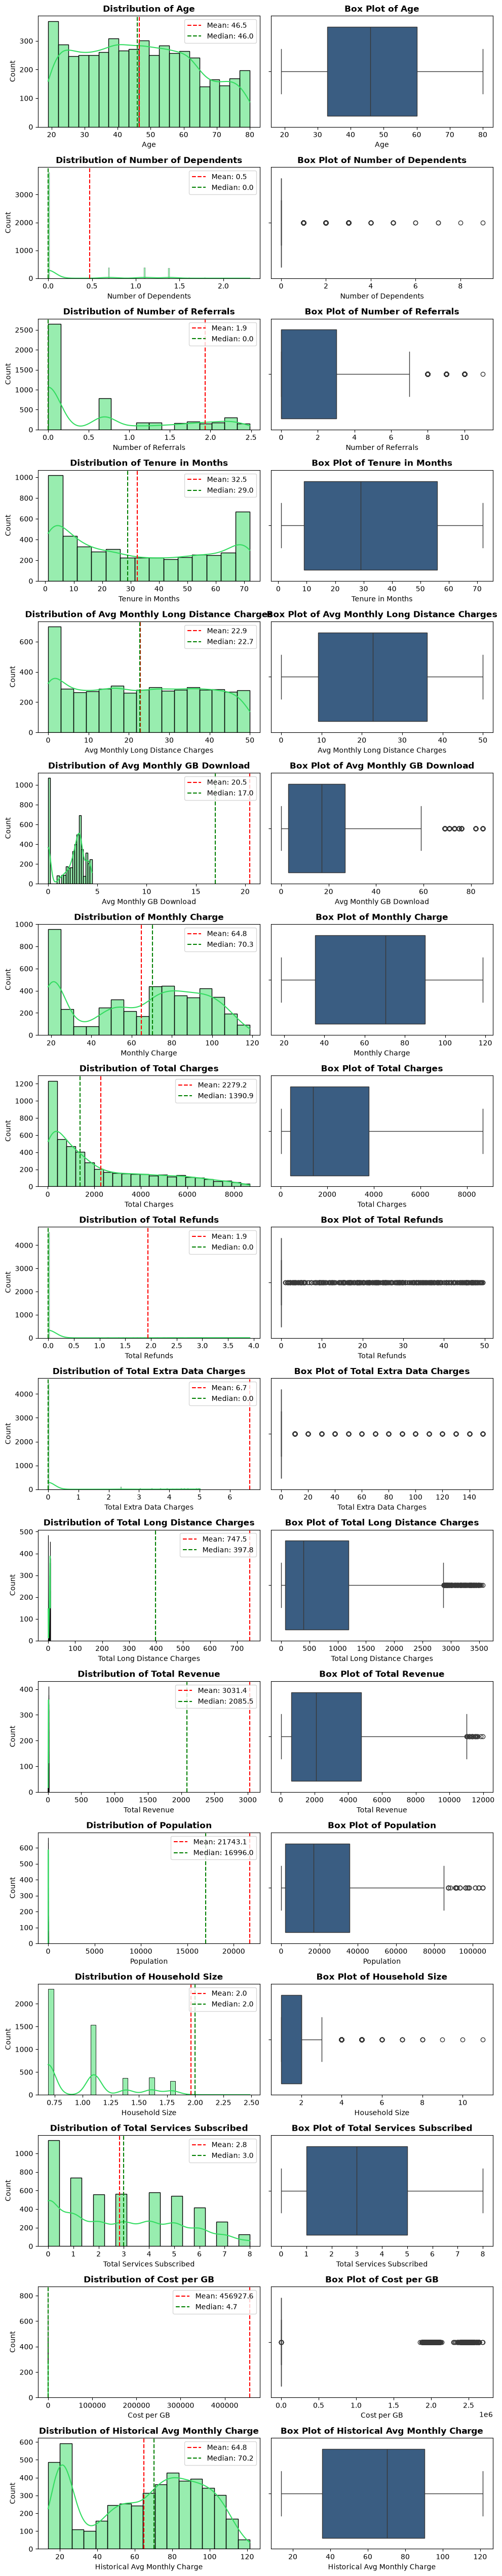

In [93]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train_log,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [94]:
# Standard Scaling
z_scaler = StandardScaler()

X_train_standard1 = X_train_log.copy()
X_val_standard1 = X_val_log.copy()
X_test_standard1 = X_test_log.copy()

X_train_standard1[num_cols] = z_scaler.fit_transform(X_train_log[num_cols].copy())
X_val_standard1[num_cols] = z_scaler.transform(X_val_log[num_cols].copy())
X_test_standard1[num_cols] = z_scaler.transform(X_test_log[num_cols].copy())

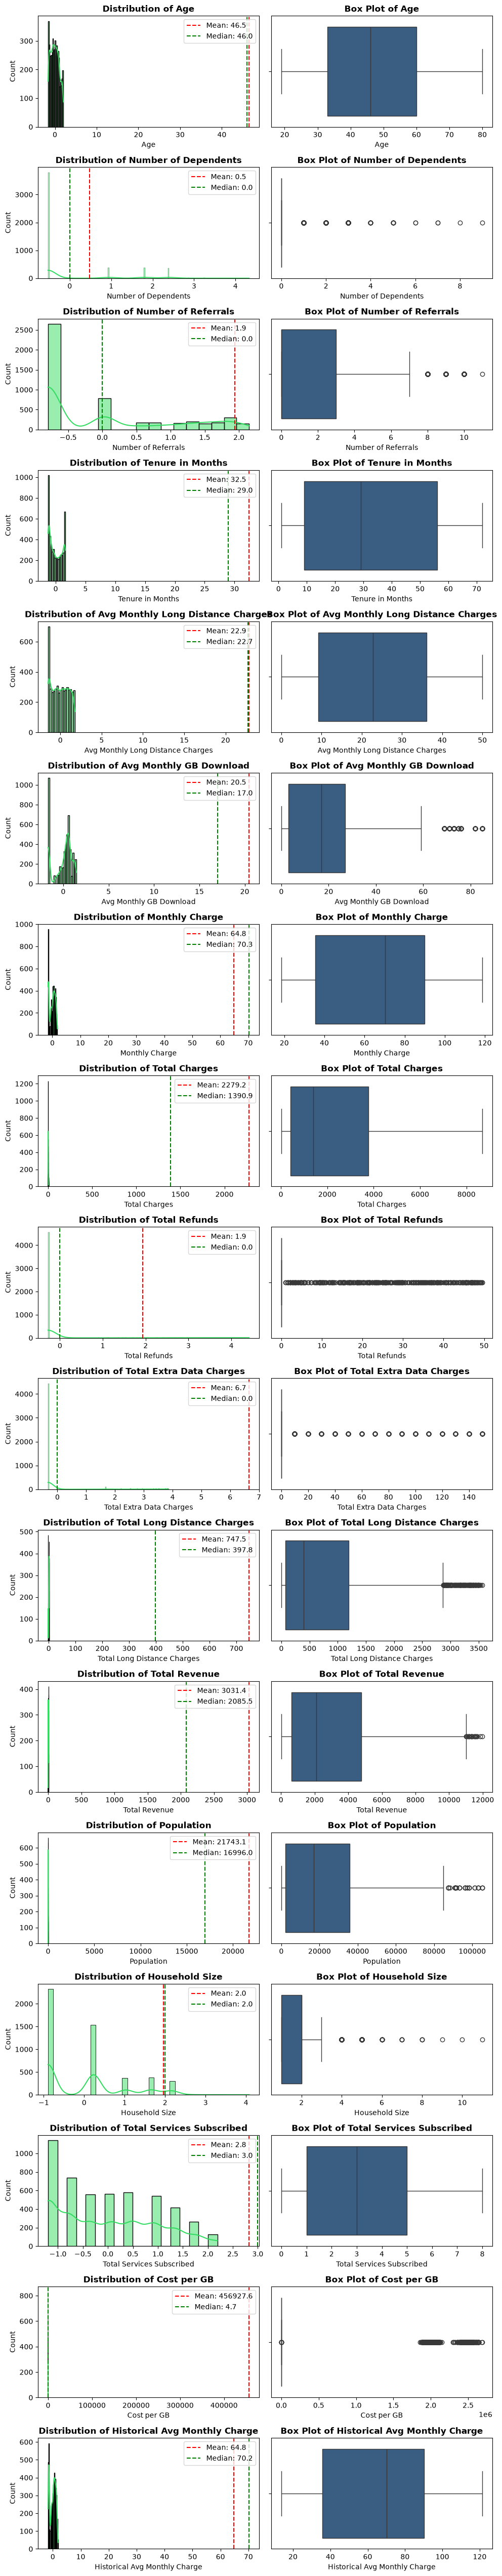

In [95]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train_standard1,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

### b. Log Transformation (All Numeric) + Standard Scaler

In [81]:
num_cols = [
    'Age',
    'Number of Dependents',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Population',
    'Household Size',
    'Total Services Subscribed',
    'Cost per GB',
    'Historical Avg Monthly Charge'
]

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [82]:
X_train_log = X_train_te.copy()
X_val_log = X_val_te.copy()
X_test_log = X_test_te.copy()

# Log-Transform
X_train_log[num_cols] = np.log1p(X_train_te[num_cols].copy())
X_val_log[num_cols] = np.log1p(X_val_te[num_cols].copy())
X_test_log[num_cols] = np.log1p(X_test_te[num_cols].copy())

In [83]:
for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [84]:
# Standard Scaling
z_scaler = StandardScaler()

X_train_standard2 = X_train_log.copy()
X_val_standard2 = X_val_log.copy()
X_test_standard2 = X_test_log.copy()

X_train_standard2[num_cols] = z_scaler.fit_transform(X_train_log[num_cols].copy())
X_val_standard2[num_cols] = z_scaler.transform(X_val_log[num_cols].copy())
X_test_standard2[num_cols] = z_scaler.transform(X_test_log[num_cols].copy())

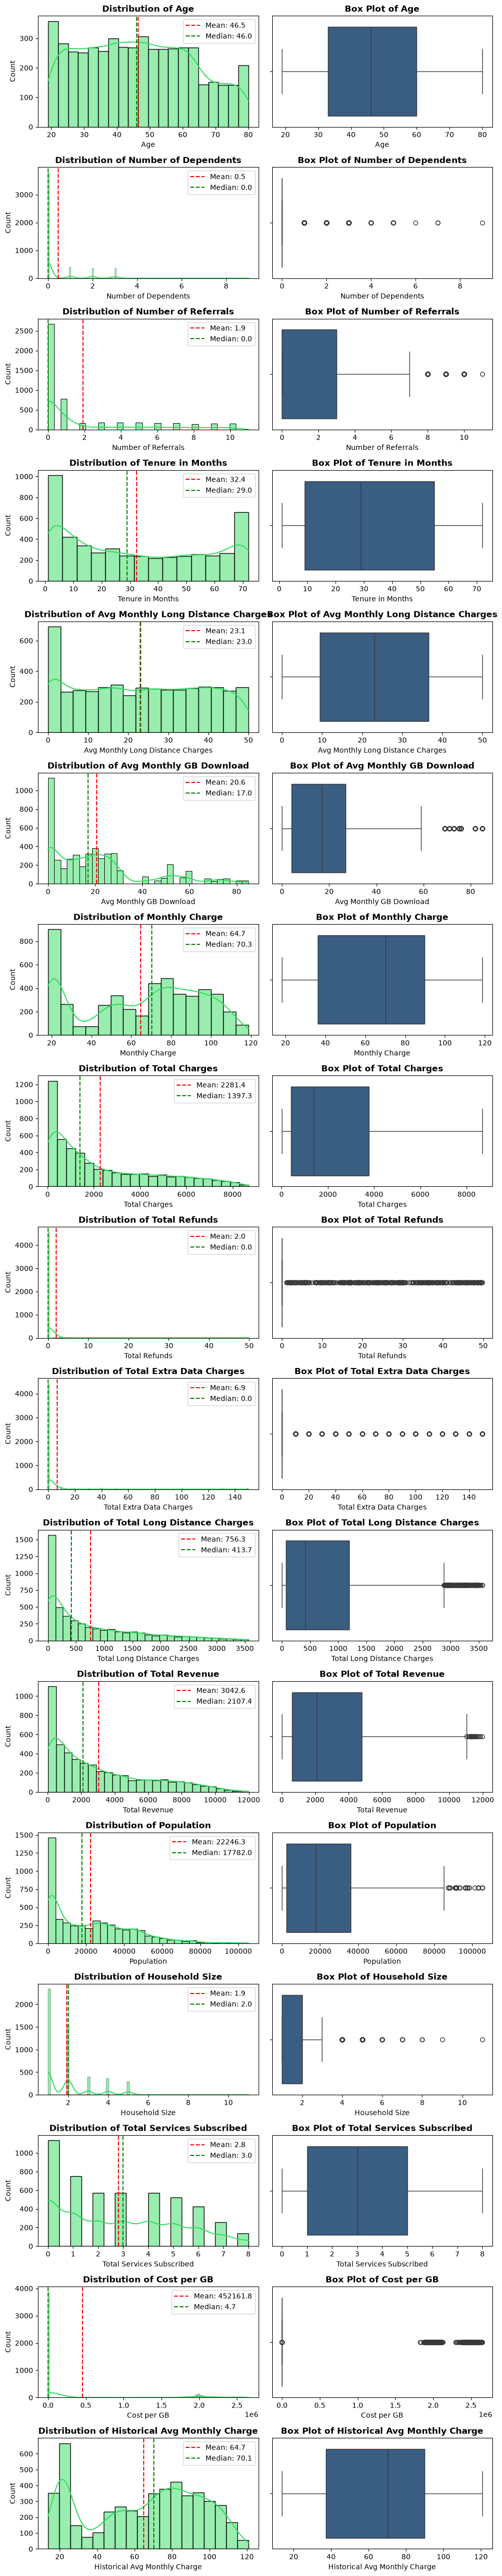

In [85]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

### c. Log Transform (Continuous Num Only) + Robust Scaler

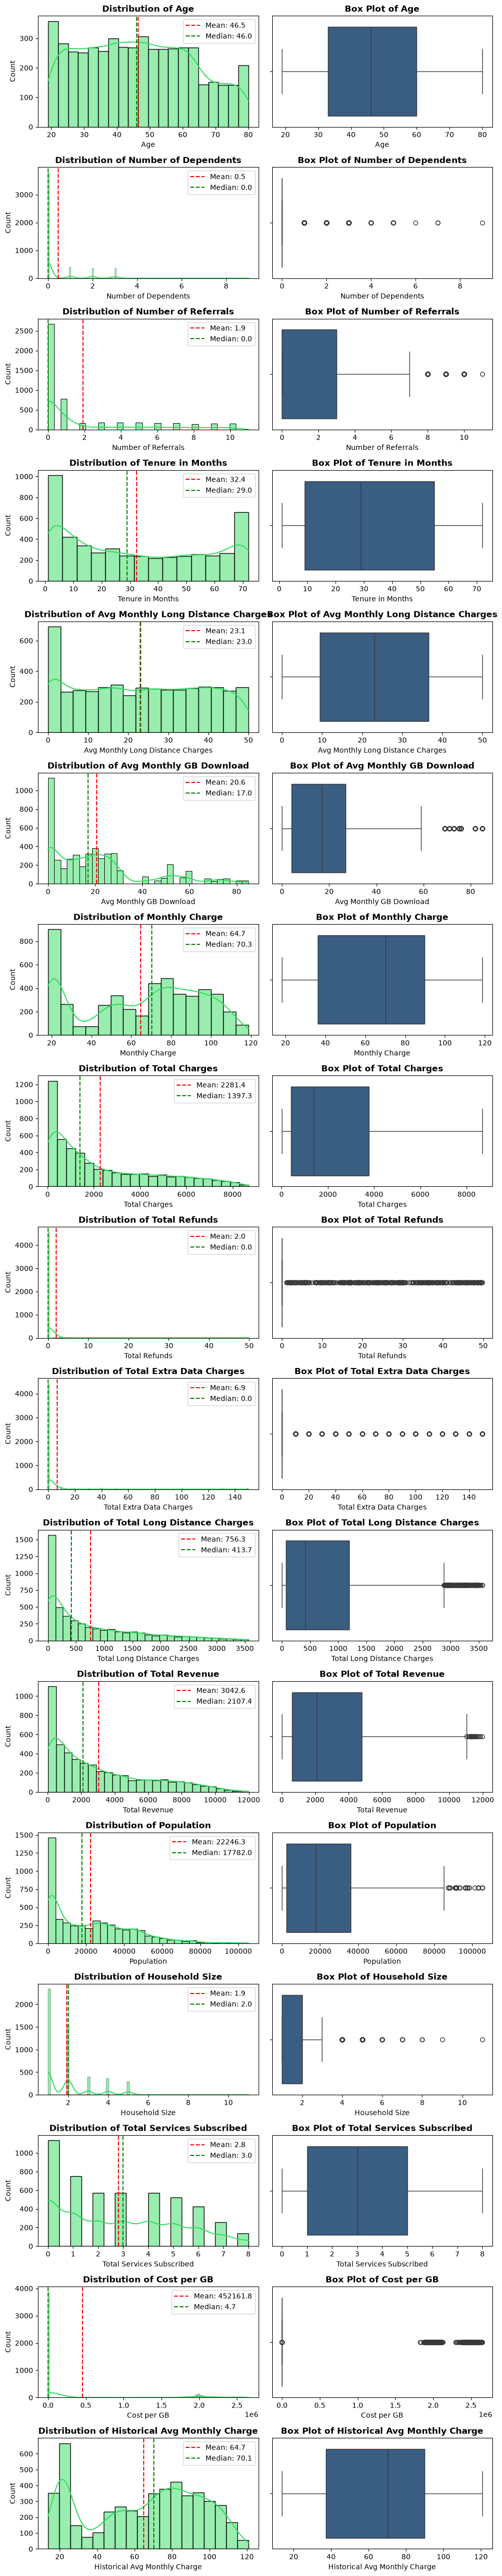

In [86]:
num_cols = [
    'Age',
    'Number of Dependents',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Population',
    'Household Size',
    'Total Services Subscribed',
    'Cost per GB',
    'Historical Avg Monthly Charge'
]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [87]:
cols_to_log = [
    'Avg Monthly Long Distance Charges',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Long Distance Charges',
    'Total Revenue',
    'Cost per GB'
]

X_train_log = X_train_te.copy()
X_val_log = X_val_te.copy()
X_test_log = X_test_te.copy()

# Log-Transform
X_train_log[cols_to_log] = np.log1p(X_train_te[cols_to_log].copy())
X_val_log[cols_to_log] = np.log1p(X_val_te[cols_to_log].copy())
X_test_log[cols_to_log] = np.log1p(X_test_te[cols_to_log].copy())

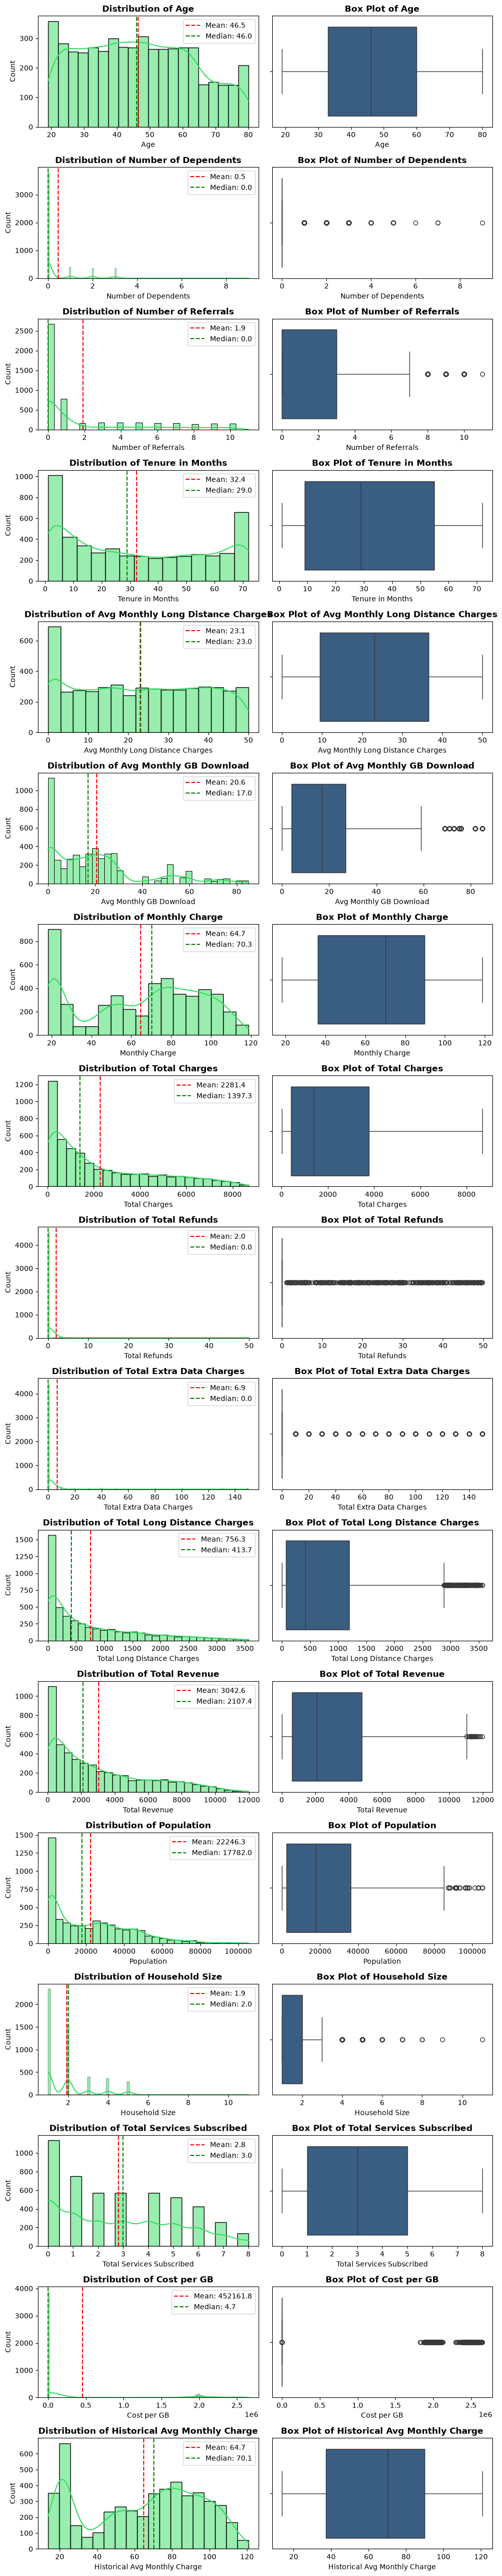

In [88]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [89]:
# Robust Scaling
r_scaler = RobustScaler()

X_train_robust = X_train_log.copy()
X_val_robust = X_val_log.copy()
X_test_robust = X_test_log.copy()

X_train_robust[num_cols] = r_scaler.fit_transform(X_train_log[num_cols])
X_val_robust[num_cols] = r_scaler.transform(X_val_log[num_cols])
X_test_robust[num_cols] = r_scaler.transform(X_test_log[num_cols])

In [ ]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

### d. Log Transform (All Numeric) + Robust Scaler

In [ ]:
num_cols = [
    'Age',
    'Number of Dependents',
    'Number of Referrals',
    'Tenure in Months',
    'Avg Monthly Long Distance Charges',
    'Avg Monthly GB Download',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Extra Data Charges',
    'Total Long Distance Charges',
    'Total Revenue',
    'Population',
    'Household Size',
    'Total Services Subscribed',
    'Cost per GB',
    'Historical Avg Monthly Charge'
]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
num_cols = [
    'Avg Monthly Long Distance Charges',
    'Monthly Charge',
    'Total Charges',
    'Total Refunds',
    'Total Long Distance Charges',
    'Total Revenue',
    'Cost per GB'
]

X_train_log = X_train_te.copy()
X_val_log = X_val_te.copy()
X_test_log = X_test_te.copy()

# Log-Transform
X_train_log[num_cols] = np.log1p(X_train_te[num_cols].copy())
X_val_log[num_cols] = np.log1p(X_val_te[num_cols].copy())
X_test_log[num_cols] = np.log1p(X_test_te[num_cols].copy())

In [ ]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Robust Scaling
r_scaler = RobustScaler()

X_train_robust = X_train_log.copy()
X_val_robust = X_val_log.copy()
X_test_robust = X_test_log.copy()

X_train_robust[num_cols] = r_scaler.fit_transform(X_train_log[num_cols])
X_val_robust[num_cols] = r_scaler.transform(X_val_log[num_cols])
X_test_robust[num_cols] = r_scaler.transform(X_test_log[num_cols])

In [ ]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(10, 3*len(num_cols)))

for i, col in enumerate(num_cols):
    sns.histplot(
        X_train,
        x=col,
        kde=True,
        color="#32dc60",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    mean = X_train[col].mean()
    median = X_train[col].median()
    axes[i, 0].axvline(mean, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean:.1f}')
    axes[i, 0].axvline(median, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median:.1f}')
    axes[i, 0].legend(loc='upper right')

    sns.boxplot(
        X_train,
        x=col,
        color="#2e5c8e",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'Box Plot of {col}', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Export Data

In [115]:
X_train_te.to_csv('../Datasets/Modeling/X_train.csv', index=False)
X_val_te.to_csv('../Datasets/Modeling/X_val.csv', index=False)
X_test_te.to_csv('../Datasets/Modeling/X_test.csv', index=False)

y_train.to_csv('../Datasets/Modeling/y_train.csv', index=False)
y_val.to_csv('../Datasets/Modeling/y_val.csv', index=False)
y_test.to_csv('../Datasets/Modeling/y_test.csv', index=False)